In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

#<u>Problem 2</u>

#Confirming bifurcation from trajectories:

## Part (a): Saddle-Node Bifurcation

Consider the autonomous system:

dx/dt = r − x²

Equilibrium points satisfy:

r − x² = 0  
⇒ x = ±√r

Observations:

- If r < 0 → No real equilibria
- If r = 0 → One equilibrium at x = 0
- If r > 0 → Two equilibria at x = ±√r

Thus, the system undergoes a saddle-node bifurcation at r = 0.


In [4]:
def f_saddle(t, x, r):
    return r - x**2


We numerically integrate the system:

dx/dt = r − x²

using Euler’s method for three values of the parameter:

r = -1.1, 0, 1.1

Initial conditions are chosen around possible equilibrium locations to observe
the qualitative change in behavior across r = 0.


/tmp/ipython-input-2681836799.py:13: RuntimeWarning: overflow encountered in square
  y = euler(lambda t, x: r - x**2, np.array([x0]), t)


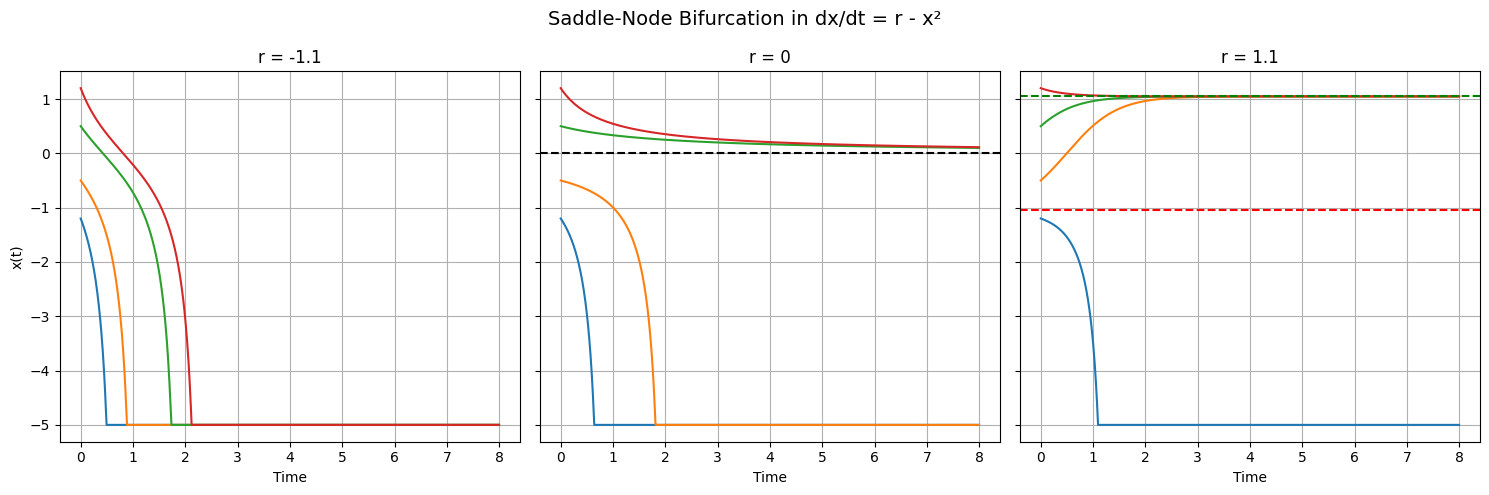

In [14]:
t = np.arange(0, 8, 0.005)
r_values = [-1.1, 0, 1.1]

initial_conditions = [-1.2, -0.5, 0.5, 1.2]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

for idx, r in enumerate(r_values):

    ax = axes[idx]

    for x0 in initial_conditions:
        y = euler(lambda t, x: r - x**2, np.array([x0]), t)
        y_vals = y[:,0]
        y_vals = np.clip(y_vals, -5, 5)
        ax.plot(t, y_vals)
    if r > 0:
        sqrt_r = np.sqrt(r)
        ax.axhline(y=sqrt_r, color='green', linestyle='--')
        ax.axhline(y=-sqrt_r, color='red', linestyle='--')
    elif r == 0:
        ax.axhline(y=0, color='black', linestyle='--')

    ax.set_title(f"r = {r}")
    ax.set_xlabel("Time")
    ax.grid(True)

axes[0].set_ylabel("x(t)")
plt.suptitle("Saddle-Node Bifurcation in dx/dt = r - x²", fontsize=14)
plt.tight_layout()
plt.show()


### Observations

The three plots illustrate the qualitative change in system behavior as the parameter r is varied. For r < 0, no equilibrium points exist and all trajectories, irrespective of their initial conditions, move monotonically downward and diverge without settling to a steady state. At r = 0, a single equilibrium point appears at x = 0; trajectories starting above this point decrease toward it, while those starting below continue to move away, indicating marginal stability. For r > 0, two equilibrium points exist at x = ±√r. However, only x = +√r is stable, while x = −√r is unstable. Trajectories starting near x = +√r converge asymptotically toward it, whereas trajectories near x = −√r move away from it. As a result, only one equilibrium is observed as an attracting steady state in the time evolution plots. This behavior is characteristic of a saddle-node bifurcation, where a stable and an unstable equilibrium are created simultaneously as r crosses zero.



## Geometric Visualization of the Bifurcation
For better visual understanding, we can do the intersection of two curves.
Thus, instead of only looking at trajectories, we can plot:

- y = x² (a parabola)
- y = r (a horizontal line)

The intersection points of these two curves represent the equilibrium points of the system.

By introducing a slider for the parameter r, we can dynamically observe how the number of intersection points changes:

- For r < 0: the horizontal line does not intersect the parabola → no equilibria.
- For r = 0: the line just touches the parabola at x = 0 → one equilibrium.
- For r > 0: the line intersects the parabola at two points → two equilibria.

As r passes through 0, two equilibrium points are created from none. This clearly demonstrates the saddle-node bifurcation at r = 0 in a geometric and visually intuitive way.


In [7]:
def plot_intersection(r):
    x = np.linspace(-3, 3, 400)
    plt.figure(figsize=(8,6))
    plt.plot(x, x**2, label="y = x²")
    plt.axhline(y=r, color='red', linestyle='--', label=f"y = {r}")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Saddle-Node Bifurcation Visualization")
    plt.ylim(-2, 10)
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_intersection, r=(-2.0, 5.0, 0.1));


interactive(children=(FloatSlider(value=1.5, description='r', max=5.0, min=-2.0), Output()), _dom_classes=('wi…

## Part (b): Transcritical Bifurcation
dx/dt = r x − x²

Equilibria occur when:

x(r − x) = 0

Thus:

x = 0  
x = r

So the system always has two equilibrium points.

f'(x) = r − 2x

Evaluate at equilibria:

At x = 0:
f'(0) = r

At x = r:
f'(r) = r − 2r = −r

So:

If r < 0:
- x = 0 is stable
- x = r is unstable

If r > 0:
- x = 0 is unstable
- x = r is stable

Thus, the two equilibrium branches exchange stability at r = 0.

This confirms a transcritical bifurcation at r = 0.


/tmp/ipython-input-4293338774.py:12: RuntimeWarning: overflow encountered in square
  y = euler(lambda t, x: r*x - x**2, np.array([x0]), t)
/tmp/ipython-input-4293338774.py:12: RuntimeWarning: invalid value encountered in subtract
  y = euler(lambda t, x: r*x - x**2, np.array([x0]), t)
/tmp/ipython-input-4293338774.py:12: RuntimeWarning: invalid value encountered in multiply
  y = euler(lambda t, x: r*x - x**2, np.array([x0]), t)


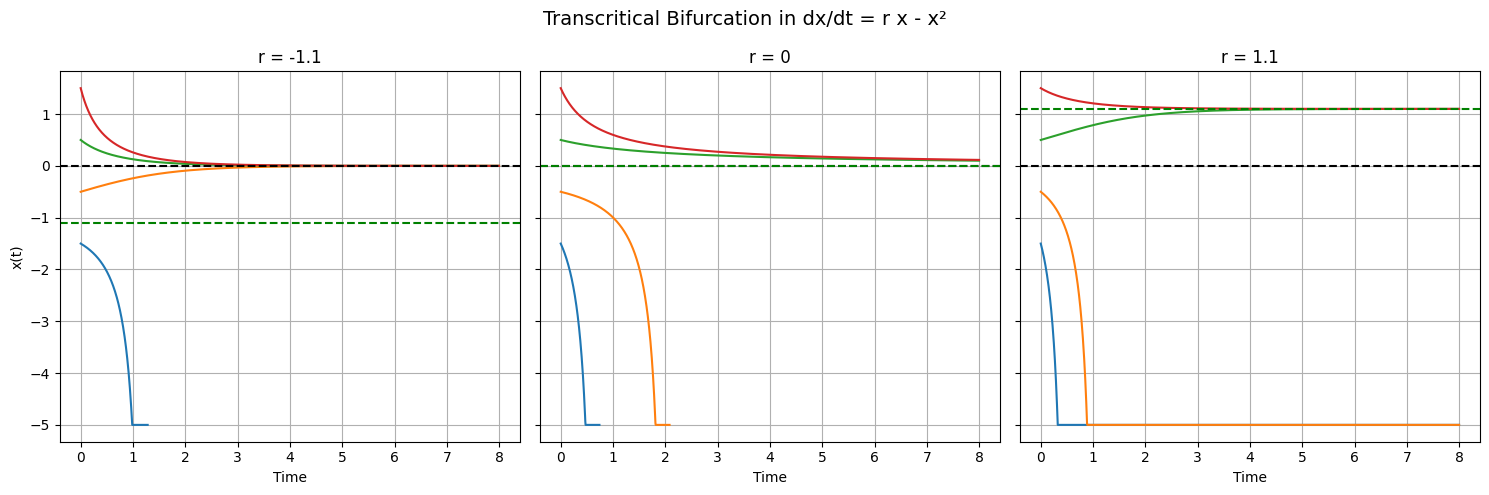

In [15]:
t = np.arange(0, 8, 0.005)
r_values = [-1.1, 0, 1.1]
initial_conditions = [-1.5, -0.5, 0.5, 1.5]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

for idx, r in enumerate(r_values):

    ax = axes[idx]

    for x0 in initial_conditions:
        y = euler(lambda t, x: r*x - x**2, np.array([x0]), t)
        y_vals = y[:,0]
        y_vals = np.clip(y_vals, -5, 5)
        ax.plot(t, y_vals)

    # Plot equilibria lines
    ax.axhline(y=0, color='black', linestyle='--')
    ax.axhline(y=r, color='green', linestyle='--')

    ax.set_title(f"r = {r}")
    ax.set_xlabel("Time")
    ax.grid(True)

axes[0].set_ylabel("x(t)")
plt.suptitle("Transcritical Bifurcation in dx/dt = r x - x²", fontsize=14)
plt.tight_layout()
plt.show()

## Observations from the Trajectories

For r < 0:
The solution approaches x = 0, indicating that x = 0 is stable.
The equilibrium at x = r is unstable.

For r = 0:
Both equilibria coincide at x = 0.
The system is at the bifurcation point.

For r > 0:
The solution moves away from x = 0 and approaches x = r.
Thus x = r becomes stable while x = 0 becomes unstable.

This exchange of stability between the two equilibrium branches confirms a transcritical bifurcation at r = 0.


In [16]:
def plot_intersection_transcritical(r):
    x = np.linspace(-3, 3, 400)

    plt.figure(figsize=(8,6))
    plt.plot(x, x**2, label="y = x²")
    plt.plot(x, r*x, label=f"y = r x (r = {r})")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Transcritical Bifurcation Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_intersection_transcritical, r=(-2.0, 2.0, 0.1));


interactive(children=(FloatSlider(value=0.0, description='r', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

## Conclusion

From the numerical integration and trajectory analysis of the system

dx/dt = r x − x²,

we observe that the system always has two equilibrium points: x = 0 and x = r. As the parameter r crosses 0, the stability of these two equilibria exchanges. For r < 0, x = 0 is stable and x = r is unstable. For r > 0, x = 0 becomes unstable while x = r becomes stable.

The trajectories clearly demonstrate this exchange of stability at r = 0 without creation or destruction of equilibria.
